In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
#df = pd.read_csv("u.data",sep="\t",names = ["user_id","item_id","rating","timestamp"])


df = pd.read_csv(
    "ratings.dat", 
    sep="::", 
    engine="python", 
    encoding="ISO-8859-1", 
    names=["user_id", "item_id", "rating", "timestamp"]
)

In [45]:
df.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [46]:
df.describe()

,user_id,item_id,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: user_id, dtype: int64


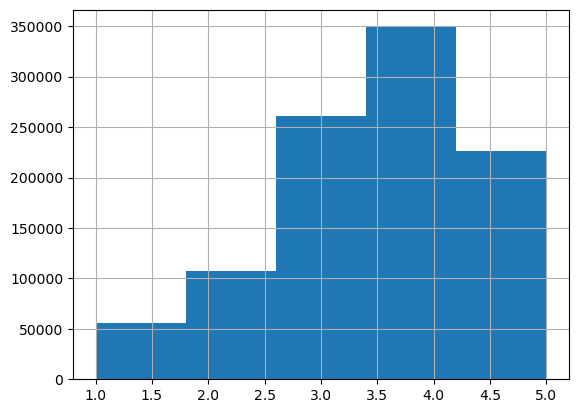

In [47]:
#ratings distribution
df['rating'].hist(bins=5)

print(df["user_id"][:10])

<Axes: >

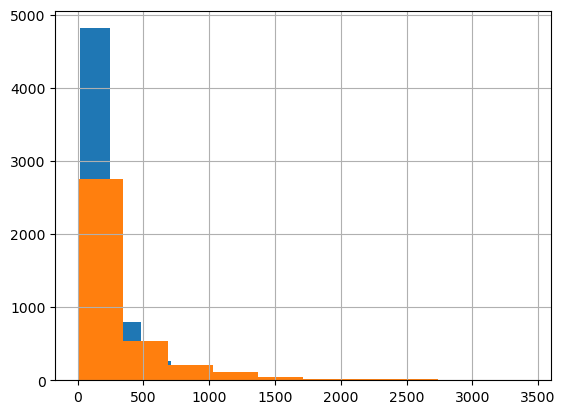

In [48]:
# Interactions per user/item
df['user_id'].value_counts().hist()
df['item_id'].value_counts().hist()

In [49]:
# Sparsity
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
sparsity = 1.0 - len(df) / (n_users * n_items)
print(f"Sparsity: {sparsity:.2%}")

'''data sparsity means how much the users have interacted with the items,  a 95% data scarcity is pretty high -but common in 
#recommender systems since very few people actually rate the films'''

Sparsity: 95.53%


'data sparsity means how much the users have interacted with the items,  a 95% data scarcity is pretty high -but common in \n#recommender systems since very few people actually rate the films'

In [50]:
print(df["user_id"])

0             1
1             1
2             1
3             1
4             1
           ... 
1000204    6040
1000205    6040
1000206    6040
1000207    6040
1000208    6040
Name: user_id, Length: 1000209, dtype: int64


In [51]:
df["interactions"] = (df["rating"]>=4).astype(int) #less than 4 becomes 0 and >4 becomes 1
'''This step can be termed as signal simplification. All the ratings above 4 will be classified as 1 and below as 0. This move can help
handle sparsity. In sparse datasets it's actually a good move, even the netflix recommendation classifiy content as observed interaction 
vs no interaction. This signal simplification can also be termed as binarisation(covnerting the data set into binaries- converting a linear regression
problem into a binary classification one'''


"This step can be termed as signal simplification. All the ratings above 4 will be classified as 1 and below as 0. This move can help\nhandle sparsity. In sparse datasets it's actually a good move, even the netflix recommendation classifiy content as observed interaction \nvs no interaction. This signal simplification can also be termed as binarisation(covnerting the data set into binaries- converting a linear regression\nproblem into a binary classification one"

In [52]:
df.head()

,user_id,item_id,rating,timestamp,interactions
0,1,1193,5,978300760,1
1,1,661,3,978302109,0
2,1,914,3,978301968,0
3,1,3408,4,978300275,1
4,1,2355,5,978824291,1


In [53]:
#function to map the userid idxs for re indexing.
user_ids = df["user_id"].unique()
item_ids = df["item_id"].unique()
def mapping(data):
    item_map = {}
    for idx,uid in enumerate(data):
        item_map[uid]=idx
    return item_map



#print(user_ids[::10])
#print(item_ids[::10])

In [54]:
user_id_map = mapping(user_ids)
item_id_map = mapping(item_ids)    

print(user_id_map)

#user_id_map = {user_id_1:idx_1, user_id_2: idx_2} 
#item_id_map = {item_id_1:idx_1, item_id_2: idx_2

#print(user_id_map)

print("##################33")
#print(item_id_map)

{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17, 19: 18, 20: 19, 21: 20, 22: 21, 23: 22, 24: 23, 25: 24, 26: 25, 27: 26, 28: 27, 29: 28, 30: 29, 31: 30, 32: 31, 33: 32, 34: 33, 35: 34, 36: 35, 37: 36, 38: 37, 39: 38, 40: 39, 41: 40, 42: 41, 43: 42, 44: 43, 45: 44, 46: 45, 47: 46, 48: 47, 49: 48, 50: 49, 51: 50, 52: 51, 53: 52, 54: 53, 55: 54, 56: 55, 57: 56, 58: 57, 59: 58, 60: 59, 61: 60, 62: 61, 63: 62, 64: 63, 65: 64, 66: 65, 67: 66, 68: 67, 69: 68, 70: 69, 71: 70, 72: 71, 73: 72, 74: 73, 75: 74, 76: 75, 77: 76, 78: 77, 79: 78, 80: 79, 81: 80, 82: 81, 83: 82, 84: 83, 85: 84, 86: 85, 87: 86, 88: 87, 89: 88, 90: 89, 91: 90, 92: 91, 93: 92, 94: 93, 95: 94, 96: 95, 97: 96, 98: 97, 99: 98, 100: 99, 101: 100, 102: 101, 103: 102, 104: 103, 105: 104, 106: 105, 107: 106, 108: 107, 109: 108, 110: 109, 111: 110, 112: 111, 113: 112, 114: 113, 115: 114, 116: 115, 117: 116, 118: 117, 119: 118, 120: 119, 121: 120, 122: 12

In [55]:
#convert the user/item ids into consecutive integers
df["user_id_mapped"] = df["user_id"].map(user_id_map)
df["item_id_mapped"] = df["item_id"].map(item_id_map) 

'''For embedding layers in keras the actual item and user ids are useless embedding layers don't care about string based ids only about
numbers - hence the values from the user_id_map and item_id_map are used for embedding layers.'''

#this reindexing is important for keras embedding layers


#reversing the map to fetch the ids later
idx2item = {idx: original_item_id for original_item_id, idx in item_id_map.items()}
#it reverses the original dictionary

idx2user = {ids: original_user_id for original_user_id,ids in user_id_map.items()}

'''Once the predictions are out it will be in the form of an integer based list  [1,2,3 ] 
- reversing the map is important in order to fetch oiginal ids.'''


df.head()



,user_id,item_id,rating,timestamp,interactions,user_id_mapped,item_id_mapped
0,1,1193,5,978300760,1,0,0
1,1,661,3,978302109,0,0,1
2,1,914,3,978301968,0,0,2
3,1,3408,4,978300275,1,0,3
4,1,2355,5,978824291,1,0,4


In [56]:
print(idx2item)

{0: 1193, 1: 661, 2: 914, 3: 3408, 4: 2355, 5: 1197, 6: 1287, 7: 2804, 8: 594, 9: 919, 10: 595, 11: 938, 12: 2398, 13: 2918, 14: 1035, 15: 2791, 16: 2687, 17: 2018, 18: 3105, 19: 2797, 20: 2321, 21: 720, 22: 1270, 23: 527, 24: 2340, 25: 48, 26: 1097, 27: 1721, 28: 1545, 29: 745, 30: 2294, 31: 3186, 32: 1566, 33: 588, 34: 1907, 35: 783, 36: 1836, 37: 1022, 38: 2762, 39: 150, 40: 1, 41: 1961, 42: 1962, 43: 2692, 44: 260, 45: 1028, 46: 1029, 47: 1207, 48: 2028, 49: 531, 50: 3114, 51: 608, 52: 1246, 53: 1357, 54: 3068, 55: 1537, 56: 647, 57: 2194, 58: 648, 59: 2268, 60: 2628, 61: 1103, 62: 2916, 63: 3468, 64: 1210, 65: 1792, 66: 1687, 67: 1213, 68: 3578, 69: 2881, 70: 3030, 71: 1217, 72: 434, 73: 2126, 74: 3107, 75: 3108, 76: 3035, 77: 1253, 78: 1610, 79: 292, 80: 2236, 81: 3071, 82: 902, 83: 368, 84: 1259, 85: 3147, 86: 1544, 87: 1293, 88: 1188, 89: 3255, 90: 3256, 91: 3257, 92: 110, 93: 2278, 94: 2490, 95: 1834, 96: 3471, 97: 589, 98: 1690, 99: 3654, 100: 2852, 101: 1945, 102: 982, 103: 

In [57]:
df.head()

,user_id,item_id,rating,timestamp,interactions,user_id_mapped,item_id_mapped
0,1,1193,5,978300760,1,0,0
1,1,661,3,978302109,0,0,1
2,1,914,3,978301968,0,0,2
3,1,3408,4,978300275,1,0,3
4,1,2355,5,978824291,1,0,4


In [58]:
#drop the unneeded columns
df_keras = df[["user_id_mapped","item_id_mapped","interactions"]]
'''Preparing the dataframe for models'''

'Preparing the dataframe for models'

In [59]:
df_keras.head()

,user_id_mapped,item_id_mapped,interactions
0,0,0,1
1,0,1,0
2,0,2,0
3,0,3,1
4,0,4,1


In [60]:
from sklearn.model_selection import train_test_split
X= df_keras[["user_id_mapped","item_id_mapped"]]
y= df_keras[["interactions"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

''' test size = 0.2 means training set 80%, test set 20%
random state =42 means the 

Random state-- 
That random_state=42 fixes the randomness.

Without it:

Every time you run the code

The training and test rows change

Your accuracy changes

Your confidence in life decreases'''






' test size = 0.2 means training set 80%, test set 20%\nrandom state =42 means the \n\nRandom state-- \nThat random_state=42 fixes the randomness.\n\nWithout it:\n\nEvery time you run the code\n\nThe training and test rows change\n\nYour accuracy changes\n\nYour confidence in life decreases'

In [61]:
num_users = df_keras["user_id_mapped"].nunique() #unique values are important for keras embeddings
num_items = df["item_id_mapped"].nunique()

print(num_users)
print(num_items)


#the values of unique users and items shows that there are many non-unique user and items in this 1 million large dataset

6040
3706


In [62]:
from keras.models import Model
from keras.layers import Input,Embedding,Flatten, Multiply, Concatenate, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

BUFFER = 10000

#inputs
user_input = Input(shape=(1,))
item_input = Input(shape=(1,))

#embeddings
embedding_dim = 32

user_embedding_gmf = Embedding(num_users + BUFFER ,embedding_dim)(user_input)
item_embedding_gmf = Embedding(num_items + BUFFER ,embedding_dim)(item_input)


user_embedding_mlp = Embedding(num_users + BUFFER, embedding_dim)(user_input)
item_embedding_mlp = Embedding(num_items + BUFFER, embedding_dim)(item_input)

#flatten
user_vec_gmf = Flatten()(user_embedding_gmf)
item_vec_gmf = Flatten()(item_embedding_gmf)

user_vec_mlp = Flatten()(user_embedding_mlp)
item_vec_mlp = Flatten()(item_embedding_mlp)


#gmf branch
gmf = Multiply()([user_vec_gmf,item_vec_gmf])

#MLP branch
mlp = Concatenate()([user_vec_mlp, item_vec_mlp])
mlp = Dense(64, activation='relu')(mlp)
mlp = Dense(32, activation='relu')(mlp)
mlp = Dense(16, activation='relu')(mlp)

#neuMF
neu = Concatenate()([gmf,mlp])
output = Dense(1,activation="sigmoid")(neu)

model = Model(inputs=[user_input,item_input],outputs=output)

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

model.compile(loss="binary_crossentropy",optimizer=Adam(learning_rate=0.001),metrics=["accuracy"])
model.summary()






Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 1, 32)             │         513,280 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_3 (Embedding)       │ (None, 1, 32)             │         438,592 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 32)                │               0 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 32)                │               0 │ embedding_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 64)                │               0 │ flatten_2[0][0],           │
│                               │                           │                 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 1, 32)             │         513,280 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 32)             │         438,592 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 64)                │           4,160 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 32)                │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 32)                │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           2,080 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multiply (Multiply)           │ (None, 32)                │               0 │ flatten[0][0],             │
│                               │                           │                 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 16)                │             528 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 48)                │               0 │ multiply[0][0],            │
│                               │                           │               

 Total params: 1,910,561 (7.29 MB)

 Trainable params: 1,910,561 (7.29 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
print("Model is:", model)
print("Model is compiled:", hasattr(model, "fit"))

Model is: <Functional name=functional, built=True>
Model is compiled: True


In [64]:
print(type(X_train["user_id_mapped"]),type(X_train["item_id_mapped"]))
print(type(y_train))

print(X_train["user_id_mapped"].shape)
print(X_train["item_id_mapped"].shape)

print(y_train.shape)
#y_train = y_train.iloc[:,0].values - this only works for pandas series not for numpy arrays
#y_test = y_test.iloc[:,0].values
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print(y_train)

<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
(800167,)
(800167,)
(800167, 1)
416292    0
683230    1
2434      0
688533    1
472584    1
         ..
259178    1
365838    1
131932    0
671155    1
121958    1
Name: interactions, Length: 800167, dtype: int32


In [65]:
history = model.fit(
    [X_train['user_id_mapped'],X_train["item_id_mapped"]],
    y_train, 
    batch_size = 256, 
    epochs=20, 
    verbose =1,
    validation_data = (
    [X_test["user_id_mapped"],X_test["item_id_mapped"]],y_test),
    callbacks = early_stopping)





Epoch 1/20
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 52s 15ms/step - accuracy: 0.7144 - loss: 0.5530 - val_accuracy: 0.7295 - val_loss: 0.5331
Epoch 2/20
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 46s 15ms/step - accuracy: 0.7578 - loss: 0.4930 - val_accuracy: 0.7384 - val_loss: 0.5238
Epoch 3/20
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8054 - loss: 0.4206 - val_accuracy: 0.7285 - val_loss: 0.5545
Epoch 4/20
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - accuracy: 0.8332 - loss: 0.3724 - val_accuracy: 0.7211 - val_loss: 0.5972
Epoch 5/20
3126/3126 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8518 - loss: 0.3391 - val_accuracy: 0.7157 - val_loss: 0.6424
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [66]:


#reshaped the train and test values to suit the tensor flow requirement based on an error
val_loss, val_acc = model.evaluate(
    [X_test["user_id_mapped"].values.reshape(-1,1), X_test["item_id_mapped"].values.reshape(-1,1)], y_test.values.reshape(-1,1)
)
print(f"Best Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

6252/6252 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.7384 - loss: 0.5238
Best Validation Loss: 0.5238, Accuracy: 0.7384


In [67]:
df_keras.head()

,user_id_mapped,item_id_mapped,interactions
0,0,0,1
1,0,1,0
2,0,2,0
3,0,3,1
4,0,4,1


In [68]:
user_id = X_test.iloc[5]["user_id_mapped"]
item_id = X_test.iloc[500]["item_id_mapped"]

print(user_id)
print(item_id)

# Prepare model inputs as 2D arrays
score = model.predict([np.array([[4667]]), np.array([[item_id]])], verbose=0)


print("Predicted interaction score:", score[0][0])

4667
335
Predicted interaction score: 0.87052536


In [69]:
all_items = df_keras["item_id_mapped"].unique()
print("items: ",all_items)
user_input = np.full(len(all_items),user_id)
print("users:",user_input)
item_input = all_items

#reshape to num items
user_input = user_input.reshape(-1,1) #keras requires 2d input
item_input = user_input.reshape(-1,1)




items:  [   0    1    2 ... 3703 3704 3705]
users: [4667 4667 4667 ... 4667 4667 4667]


#def get_scored(user_):
    all_items = df_keras["item_id_mapped"].unique()
    user_array = np.array([[user_]])
    predictions_list = []
    for item in all_items:
        item_array = np.array([[item]])
        predictions  = model.predict([user_array,item_array],verbose=0)[0][0] #the [0][0] to extract the scalar from the nparray
        predictions_list.append((item,predictions))
    top_n_predictions = sorted(predictions_list,key =lambda x:x[1], reverse=True)[:10]
    return top_n_predictions



print(get_scored(101))

In [71]:
#map these ids back to the movie titles

In [72]:
df.head()

,user_id,item_id,rating,timestamp,interactions,user_id_mapped,item_id_mapped
0,1,1193,5,978300760,1,0,0
1,1,661,3,978302109,0,0,1
2,1,914,3,978301968,0,0,2
3,1,3408,4,978300275,1,0,3
4,1,2355,5,978824291,1,0,4


In [73]:
df_test = df[["user_id","item_id","rating","interactions","user_id_mapped","item_id_mapped"]]
df_test.head()


,user_id,item_id,rating,interactions,user_id_mapped,item_id_mapped
0,1,1193,5,1,0,0
1,1,661,3,0,0,1
2,1,914,3,0,0,2
3,1,3408,4,1,0,3
4,1,2355,5,1,0,4


In [74]:
# Build a dictionary { user_idx : set of item_idx }
# Build user-item interaction dictionary from full DF
# Make sure you do this in a fresh cell before calling get_top_k_recommendations

user_item_interactions = (
    df.groupby("user_id_mapped")["item_id_mapped"]
    .apply(set)          # convert each user's items to a set
    .to_dict()           # convert Series to dict
)

print(type(user_item_interactions))  # should be dict
print(list(user_item_interactions.items())[:5])  # preview

<class 'dict'>
[(0, {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52}), (1, {0, 18, 20, 42, 47, 48, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174}), (2, {128, 4, 5, 22, 166, 168, 41, 44, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 58, 188, 189, 190, 64, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 20

In [75]:
def get_top_k_recommendations(model, user_id,user_item_interactions, all_items, k=10):
    """
    model: trained Keras NCF model
    user_id: mapped user index (int)
    all_items: list/array of all mapped item indices
    user_item_interactions: set or list of items the user has interacted with
    k: top K items to return
    """

    # Filter out items already interacted with
    seen_movies = set(user_item_interactions.get(user_id, set()))
    unseen_items = set(all_items) - seen_movies
    unseen_items = np.array(list(unseen_items))

    # Create user tensor
    users = np.full(len(unseen_items), user_id, dtype=np.int32)
    print(users)
    print(unseen_items)


    # Predict scores
    predictions = model.predict([users.reshape(-1,1), unseen_items.reshape(-1,1)], verbose=0).flatten() #keras output in 2d array form, for sorting we need to flatten it
    print(predictions)

    # Get top-K items
    top_k_indices = predictions.argsort()[-k:][::-1]
    print(top_k_indices)
    top_k_items = unseen_items[top_k_indices]
    print(top_k_items)

    return top_k_items


In [76]:
user_id = int(input("Enter the user ID"))

Enter the user ID 43


In [77]:
top_indices_mapped = get_top_k_recommendations(model, user_id, user_item_interactions, all_items, k=10)

[43 43 43 ... 43 43 43]
[   1    2    3 ... 3703 3704 3705]
[0.29487744 0.94600767 0.8787102  ... 0.5309973  0.69252557 0.71039355]
[ 533    6  424  128  154  588   21  272 2744 1281]
[ 648   10  505  171  210  711   33  338 2937 1448]


In [78]:

def map_back_to_original_ids(top_indices_mapped):
    top_indices_original_ids =  []
    for i in top_indices_mapped:
        top_indices_original_ids.append(idx2item[i])
    return top_indices_original_ids


In [79]:
top_ids_original = map_back_to_original_ids(top_indices_mapped)

In [80]:
df.head()

,user_id,item_id,rating,timestamp,interactions,user_id_mapped,item_id_mapped
0,1,1193,5,978300760,1,0,0
1,1,661,3,978302109,0,0,1
2,1,914,3,978301968,0,0,2
3,1,3408,4,978300275,1,0,3
4,1,2355,5,978824291,1,0,4


In [81]:
movies = pd.read_csv(
    "movies.dat",
    sep="::", 
    engine="python",  # Needed because "::" is multi-character separator
    header=None,      # No header row in file
    names=["movieId", "title", "genres"],  # Assign column names
    encoding="latin-1" 
)

print(movies.head())
df_ratings = df.copy()
movie_avg = (df_ratings.groupby("item_id")["rating"].mean().reset_index(name="avg_rating"))


#df.rename(columns={"old_name": "new_name"}, inplace=True)

movie_avg.rename(columns={"item_id":"movieId"},inplace=True)


movies_with_ratings = pd.merge(movies,movie_avg, on='movieId',how='inner')

movies_with_ratings.head()

   movieId                               title                        genres
0        1                    Toy Story (1995)   Animation|Children's|Comedy
1        2                      Jumanji (1995)  Adventure|Children's|Fantasy
2        3             Grumpier Old Men (1995)                Comedy|Romance
3        4            Waiting to Exhale (1995)                  Comedy|Drama
4        5  Father of the Bride Part II (1995)                        Comedy


,movieId,title,genres,avg_rating
0,1,Toy Story (1995),Animation|Children's|Comedy,4.146846
1,2,Jumanji (1995),Adventure|Children's|Fantasy,3.201141
2,3,Grumpier Old Men (1995),Comedy|Romance,3.016736
3,4,Waiting to Exhale (1995),Comedy|Drama,2.729412
4,5,Father of the Bride Part II (1995),Comedy,3.006757


In [82]:
def get_movie_titles(top_ids_original):
    for movie_id in top_ids_original:
        #filter the dataframe from this movieID
        row = movies[movies['movieId']==movie_id]

        #get the title value and append to the list
        title = row['title'].values[0]
        print(title)
    return "Happy Watching! :)"
    

In [83]:
print(get_movie_titles(top_ids_original))

Roman Holiday (1953)
Beauty and the Beast (1991)
Life Is Beautiful (La Vita è bella) (1997)
Forrest Gump (1994)
Die Hard (1988)
Lethal Weapon (1987)
Aladdin (1992)
Maltese Falcon, The (1941)
Carmen (1984)
It Happened One Night (1934)
Happy Watching! :)


In [84]:
#!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

In [85]:
id2movie = {internalId: movies.loc[movies["movieId"] == mid, "title"].values[0]
            for mid, internalId in item_id_map.items()}

In [86]:
import os, pickle

# Ensure model folder exists
os.makedirs("model", exist_ok=True)

# Save user & movie mappings
with open("model/user2id.pkl", "wb") as f:
    pickle.dump(user_id_map, f)

with open("model/id2user.pkl", "wb") as f:
    pickle.dump(idx2user, f)

with open("model/movie2id.pkl", "wb") as f:
    pickle.dump(item_id_map, f)

with open("model/id2movie.pkl", "wb") as f:
    pickle.dump(id2movie, f)

with open("movies_with_ratings.pkl", "wb") as f:
    pickle.dump(movies_with_ratings, f)


# Save the entire model
model.save("model/ncf_model.h5")

# Save movies metadata for frontend use
movies_df = pd.read_csv(
    "C:/Users/neelh/Jupyter Related/NeuMFRec/movies.dat",
    sep="::",
    engine="python",
    encoding="ISO-8859-1",
    names=["movieId", "title", "genres"]
)

print("✅ Model, mappings, and metadata saved in /model folder")

✅ Model, mappings, and metadata saved in /model folder


In [87]:
!which python

'which' is not recognized as an internal or external command,
operable program or batch file.


In [88]:
!where python

C:\Users\neelh\anaconda\python.exe


In [89]:
import sys
print(sys.executable)

C:\Users\neelh\anaconda\envs\recsys\python.exe
